
### **Задание 1. Построение и обучение базового многослойного перцептрона (MLP)**
1. Подготовьте набор данных (например, MNIST или CIFAR-10) и разделите его на обучающую и валидационную выборки.
2. Реализуйте MLP с одним или несколькими скрытыми слоями с использованием Keras или PyTorch.
3. Используйте функции активации (ReLU, sigmoid, tanh) и реализуйте обратное распространение ошибки для оптимизации параметров.
4. Постройте графики изменения функции потерь и точности на обучающей и валидационной выборках.
5. Проанализируйте, как изменение числа нейронов в скрытых слоях влияет на сходимость и обобщающую способность модели.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [5]:
transform_to_tensor = transforms.Compose([
    transforms.ToTensor()
])

In [9]:
mnist_train = MNIST(root='./', train=True, download=True, transform=transform_to_tensor)
mnist_val = MNIST(root='./', train=False, download=True, transform=transform_to_tensor)

batch_size = 64
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(mnist_val, batch_size=batch_size, shuffle=False)

In [21]:
class MyMLP(nn.Module):
    def __init__(self, 
                 num_pixels: int = 784,
                 n_neurons: int = 256,
                 num_classes: int = 10,
                 activation = 'relu'):
        super().__init__()

        if activation == 'relu':
            activation = nn.ReLU()
        elif activation == 'leaky_relu':
            activation = nn.LeakyReLU()
        elif activation == 'sigmoid':
            activation = nn.Sigmoid()
        elif activation == 'tanh':
            activation = nn.Tanh()

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_pixels, n_neurons),
            activation,
            nn.Linear(n_neurons, n_neurons),
            activation,
            nn.Linear(n_neurons, n_neurons),
            activation,
            nn.Linear(n_neurons, num_classes)
        )

    def forward(self, x):
        return self.fc(x)

In [22]:
def train_model(model, train_loader, val_loader, lr=0.001, n_epochs=10, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(n_epochs):
        model.train()

        train_loss = 0.0
        total_train = 0
        current_train = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            total_train += labels.size(0)
            current_train += (outputs.argmax(axis=1) == labels).float().sum()

        train_loss = train_loss / len(train_loader)
        train_acc = 100 * current_train / total_train


        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for i, (inputs, labels) in enumerate(val_loader):
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                total_val += labels.size(0)
                correct_val += (outputs.argmax(axis=1) == labels).float().sum()

        val_loss = val_loss / len(train_loader)
        val_acc = 100 * correct_val / total_val

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f'Epoch [{epoch+1}/{n_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return train_losses, val_losses, train_accuracies, val_accuracies


In [27]:
def plot_results(train_losses, val_losses, train_accuracies, val_accuracies, title=''):
    
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b', label='Training loss')
    plt.plot(epochs, val_losses, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b', label='Training accuracy')
    plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.suptitle(title)

    plt.show()


In [30]:
from datetime import datetime
import time

Epoch [1/5], Train Loss: 0.3347, Train Acc: 90.31%, Val Loss: 0.0256, Val Acc: 95.39%
Epoch [2/5], Train Loss: 0.1298, Train Acc: 96.07%, Val Loss: 0.0188, Val Acc: 96.48%
Epoch [3/5], Train Loss: 0.0906, Train Acc: 97.25%, Val Loss: 0.0166, Val Acc: 97.04%
Epoch [4/5], Train Loss: 0.0662, Train Acc: 97.86%, Val Loss: 0.0154, Val Acc: 97.20%
Epoch [5/5], Train Loss: 0.0522, Train Acc: 98.37%, Val Loss: 0.0131, Val Acc: 97.55%


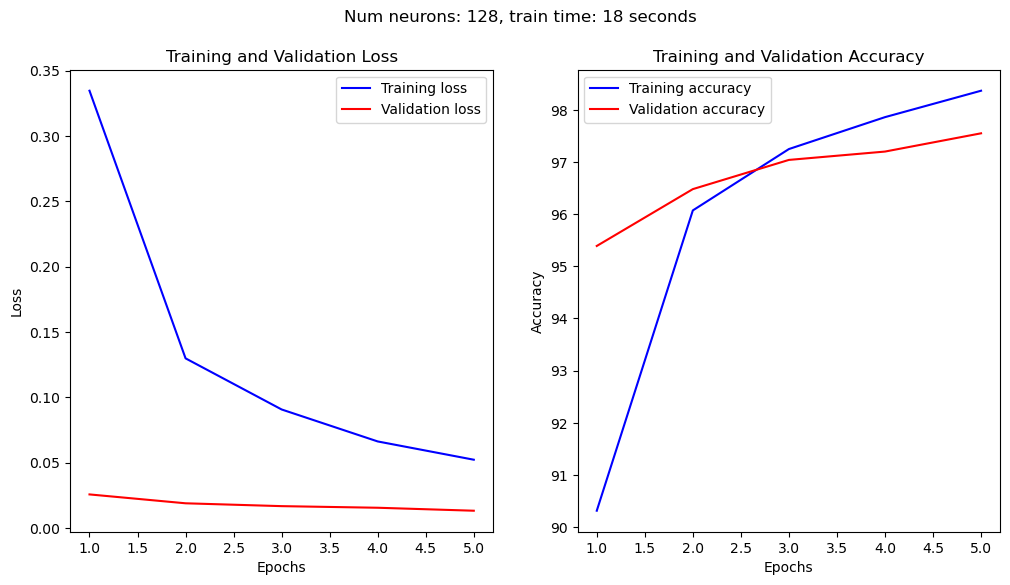

Epoch [1/5], Train Loss: 0.2694, Train Acc: 91.92%, Val Loss: 0.0210, Val Acc: 96.11%
Epoch [2/5], Train Loss: 0.1000, Train Acc: 96.97%, Val Loss: 0.0143, Val Acc: 97.37%
Epoch [3/5], Train Loss: 0.0707, Train Acc: 97.74%, Val Loss: 0.0138, Val Acc: 97.45%
Epoch [4/5], Train Loss: 0.0523, Train Acc: 98.39%, Val Loss: 0.0136, Val Acc: 97.64%
Epoch [5/5], Train Loss: 0.0396, Train Acc: 98.76%, Val Loss: 0.0145, Val Acc: 97.60%


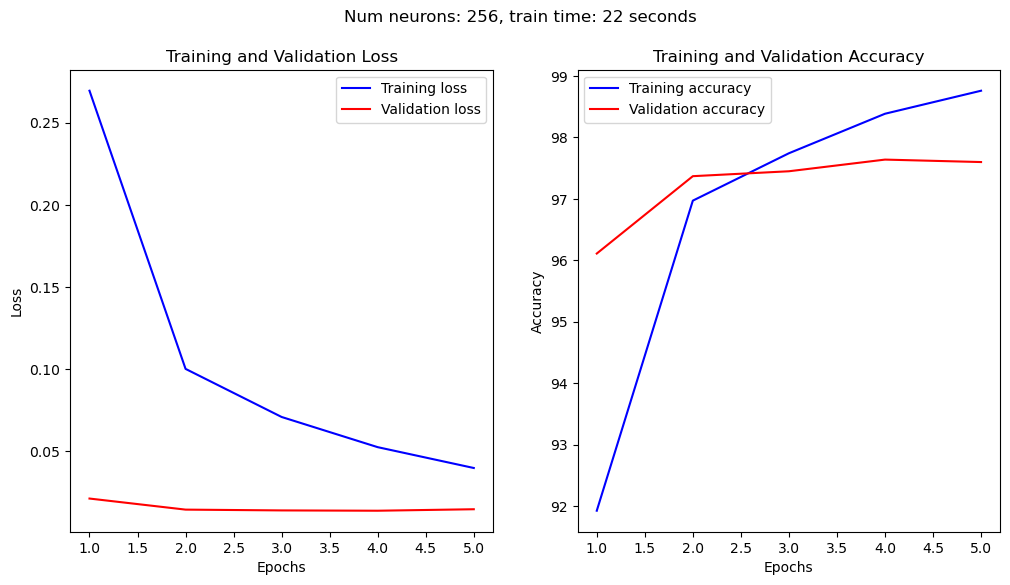

Epoch [1/5], Train Loss: 0.2286, Train Acc: 93.07%, Val Loss: 0.0208, Val Acc: 96.08%
Epoch [2/5], Train Loss: 0.0945, Train Acc: 97.14%, Val Loss: 0.0144, Val Acc: 97.54%
Epoch [3/5], Train Loss: 0.0671, Train Acc: 97.91%, Val Loss: 0.0154, Val Acc: 97.18%
Epoch [4/5], Train Loss: 0.0489, Train Acc: 98.51%, Val Loss: 0.0130, Val Acc: 97.89%
Epoch [5/5], Train Loss: 0.0401, Train Acc: 98.75%, Val Loss: 0.0172, Val Acc: 97.39%


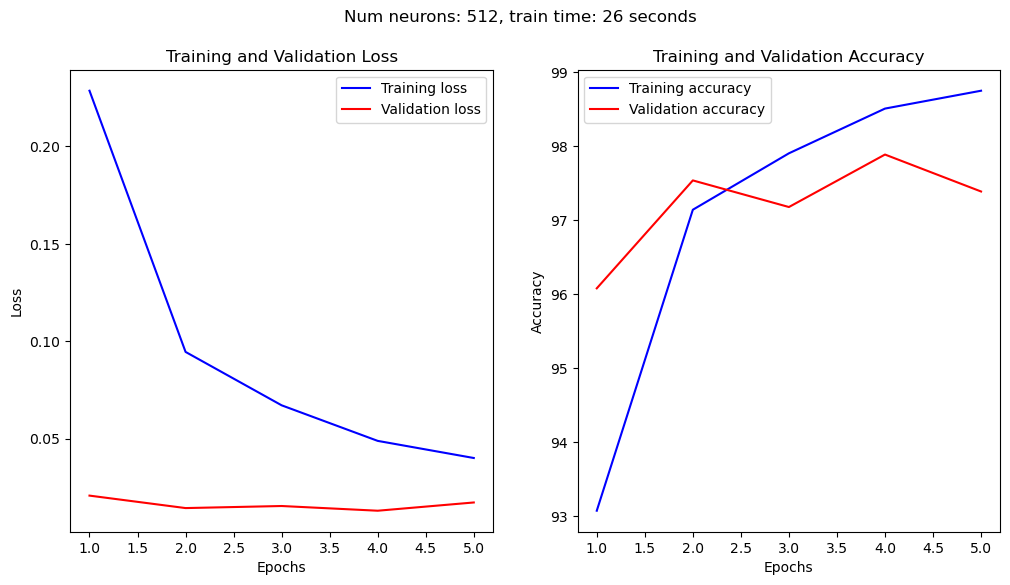

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for n_neurons in [128, 256, 512]:
    activation = 'relu'
    model = MyMLP(n_neurons=n_neurons, activation=activation).to(device)

    start_time = datetime.now()
    train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, lr=0.001, n_epochs=5, device=device)
    end_time = datetime.now()

    train_time = (end_time - start_time).seconds

    plot_results(train_losses, val_losses, train_accuracies, val_accuracies, title=f'Num neurons: {n_neurons}, train time: {train_time} seconds')

### **Задание 2. Реализация сверточной нейронной сети (CNN) для классификации изображений**
1. Используя тот же датасет, создайте CNN, включающую:
   - Один или несколько сверточных слоев с параметрами (ядро, шаг, padding).
   - Пулинг-слои (max pooling или average pooling).
   - Полносвязанные слои для окончательной классификации.
2. Реализуйте код на Python с использованием Keras или PyTorch.
3. Экспериментируйте с различными архитектурными решениями (число слоёв, размер ядер) и сравните полученные результаты.
4. Проанализируйте, как архитектурные изменения влияют на качество классификации.

In [64]:
class MyCNN(nn.Module):
    def __init__(self, 
                 in_channels: int = 1, 
                 out_channels: int = 64,
                 n_layers = None, 
                 n_classes: int = 10,
                 kernel_size: int = 3, 
                 stride: int = 1, 
                 padding: int = 1, 
                 pooling='max_pooling'):
        super().__init__()

        self.n_layers = n_layers

        if pooling == 'max_pooling':
            pooling = nn.MaxPool2d(kernel_size=kernel_size)
        elif pooling == 'avg_pooling':
            pooling = nn.AvgPool2d(kernel_size=kernel_size)

        self.inner1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            pooling,
            nn.ReLU()
        )
        
        self.inner2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            pooling,
            nn.ReLU()
        )

        self.inner3 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            pooling,
            nn.ReLU()
        )

        h_out = 28
        w_out = 28
        h_out = int((h_out - kernel_size) / stride + 1) // kernel_size + 1
        w_out = int((w_out - kernel_size) / stride + 1) // kernel_size + 1

        if n_layers is not None:
            h_out = int((h_out - kernel_size) / stride + 1) // kernel_size + 1
            w_out = int((w_out - kernel_size) / stride + 1) // kernel_size + 1
            if n_layers == 3:
                h_out = int((h_out - kernel_size) / stride + 1) // kernel_size + 1
                w_out = int((w_out - kernel_size) / stride + 1) // kernel_size + 1

        self.fc = nn.Linear(out_channels * h_out * w_out, n_classes)

    def forward(self, x):
        out = self.inner1(x)

        if self.n_layers is not None:
            out = self.inner2(out)
            if self.n_layers == 3:
                out = self.inner3(out)

        out = out.view(out.size(0), -1) 

        return self.fc(out)

Epoch [1/5], Train Loss: 0.2776, Train Acc: 92.36%, Val Loss: 0.0176, Val Acc: 96.95%
Epoch [2/5], Train Loss: 0.0981, Train Acc: 97.19%, Val Loss: 0.0126, Val Acc: 97.76%
Epoch [3/5], Train Loss: 0.0729, Train Acc: 97.86%, Val Loss: 0.0128, Val Acc: 97.72%
Epoch [4/5], Train Loss: 0.0630, Train Acc: 98.13%, Val Loss: 0.0109, Val Acc: 97.99%
Epoch [5/5], Train Loss: 0.0556, Train Acc: 98.32%, Val Loss: 0.0100, Val Acc: 98.09%


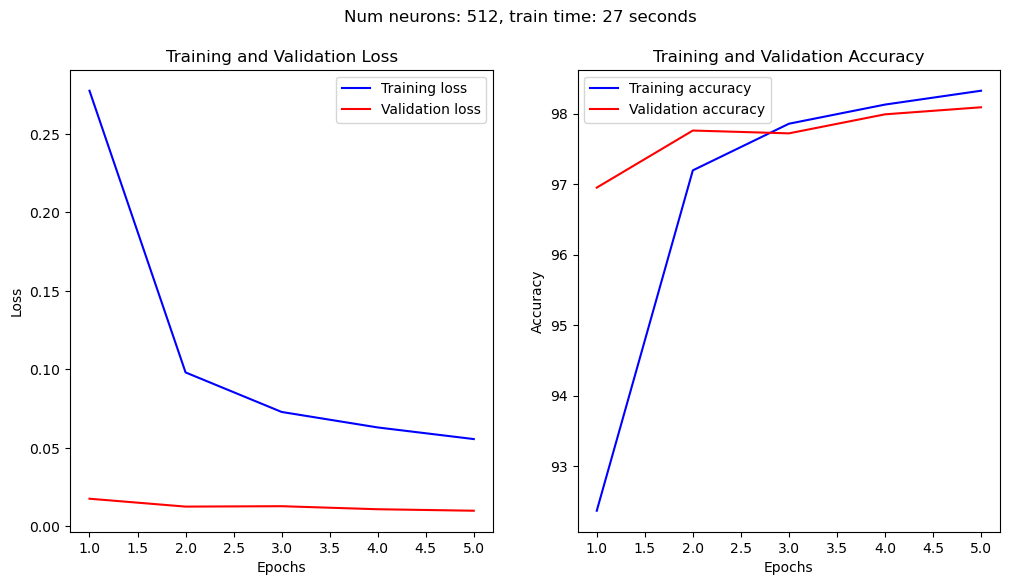

Epoch [1/5], Train Loss: 0.2345, Train Acc: 93.17%, Val Loss: 0.0157, Val Acc: 97.22%
Epoch [2/5], Train Loss: 0.0878, Train Acc: 97.43%, Val Loss: 0.0123, Val Acc: 97.80%
Epoch [3/5], Train Loss: 0.0672, Train Acc: 98.04%, Val Loss: 0.0108, Val Acc: 98.03%
Epoch [4/5], Train Loss: 0.0556, Train Acc: 98.35%, Val Loss: 0.0091, Val Acc: 98.31%
Epoch [5/5], Train Loss: 0.0485, Train Acc: 98.55%, Val Loss: 0.0094, Val Acc: 98.15%


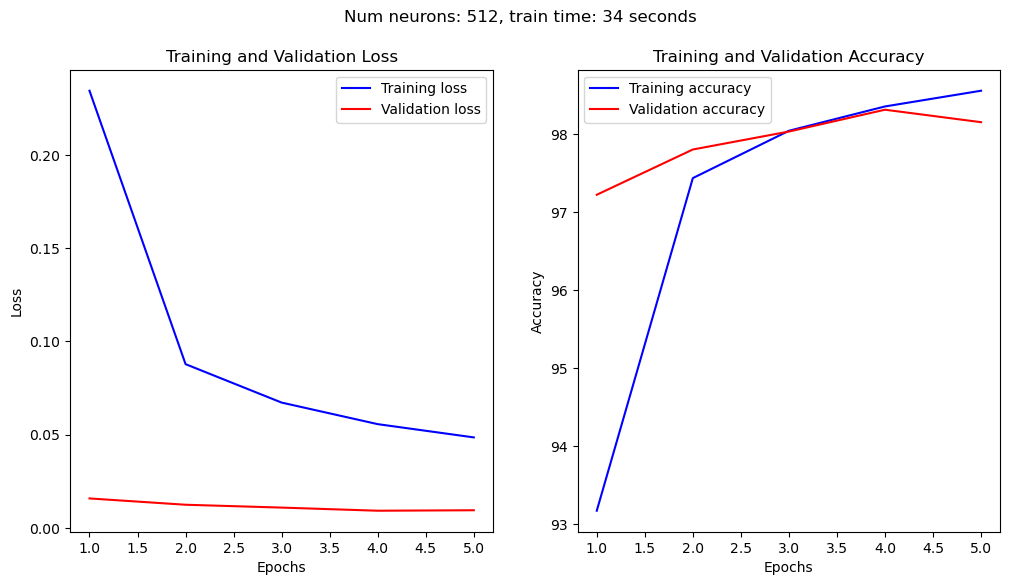

Epoch [1/5], Train Loss: 0.1873, Train Acc: 94.42%, Val Loss: 0.0135, Val Acc: 97.66%
Epoch [2/5], Train Loss: 0.0707, Train Acc: 97.82%, Val Loss: 0.0096, Val Acc: 98.02%
Epoch [3/5], Train Loss: 0.0547, Train Acc: 98.37%, Val Loss: 0.0098, Val Acc: 98.18%
Epoch [4/5], Train Loss: 0.0463, Train Acc: 98.56%, Val Loss: 0.0084, Val Acc: 98.40%
Epoch [5/5], Train Loss: 0.0387, Train Acc: 98.86%, Val Loss: 0.0084, Val Acc: 98.51%


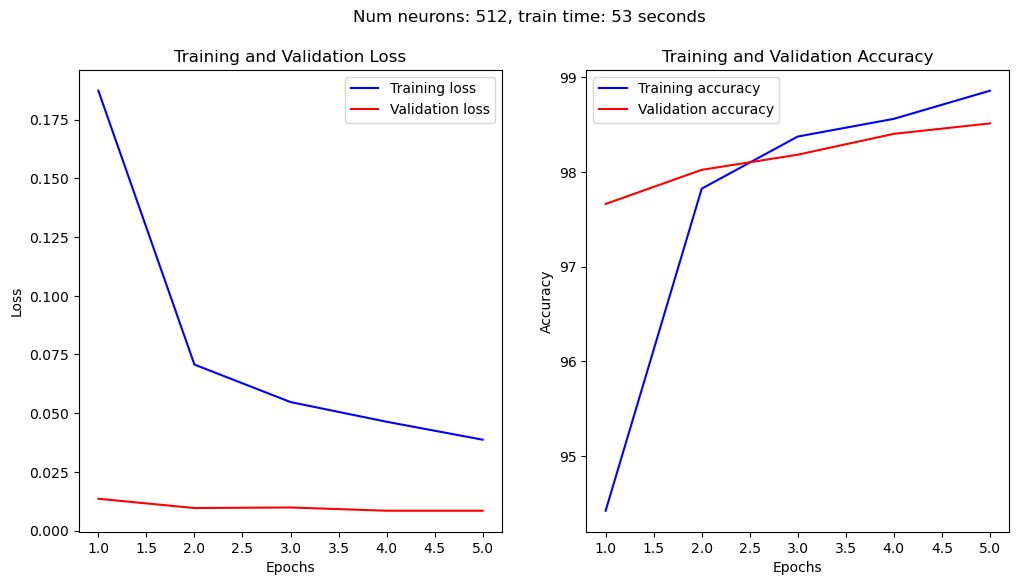

In [65]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for out_channels in [32, 64, 128]:
    model = MyCNN(out_channels=out_channels).to(device)

    start_time = datetime.now()
    train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, lr=0.001, n_epochs=5, device=device)
    end_time = datetime.now()

    train_time = (end_time - start_time).seconds

    plot_results(train_losses, val_losses, train_accuracies, val_accuracies, title=f'Num neurons: {n_neurons}, train time: {train_time} seconds')

Epoch [1/5], Train Loss: 0.2395, Train Acc: 93.12%, Val Loss: 0.0145, Val Acc: 97.47%
Epoch [2/5], Train Loss: 0.0825, Train Acc: 97.61%, Val Loss: 0.0125, Val Acc: 97.85%
Epoch [3/5], Train Loss: 0.0638, Train Acc: 98.08%, Val Loss: 0.0103, Val Acc: 97.99%
Epoch [4/5], Train Loss: 0.0546, Train Acc: 98.35%, Val Loss: 0.0105, Val Acc: 98.11%
Epoch [5/5], Train Loss: 0.0477, Train Acc: 98.59%, Val Loss: 0.0092, Val Acc: 98.17%


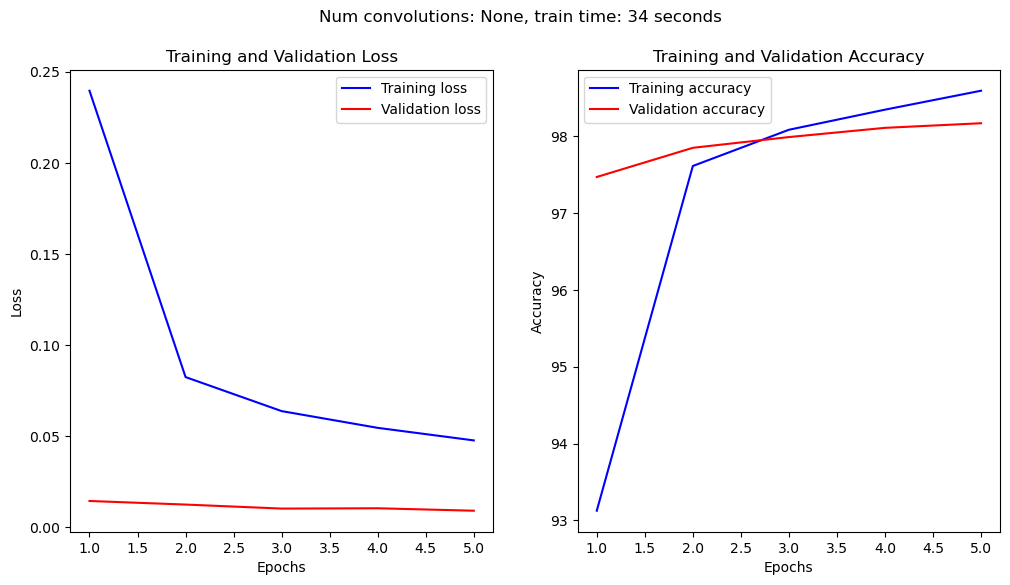

Epoch [1/5], Train Loss: 0.2480, Train Acc: 92.79%, Val Loss: 0.0127, Val Acc: 97.55%
Epoch [2/5], Train Loss: 0.0640, Train Acc: 97.97%, Val Loss: 0.0069, Val Acc: 98.69%
Epoch [3/5], Train Loss: 0.0468, Train Acc: 98.52%, Val Loss: 0.0065, Val Acc: 98.70%
Epoch [4/5], Train Loss: 0.0375, Train Acc: 98.85%, Val Loss: 0.0050, Val Acc: 99.01%
Epoch [5/5], Train Loss: 0.0325, Train Acc: 98.96%, Val Loss: 0.0057, Val Acc: 98.92%


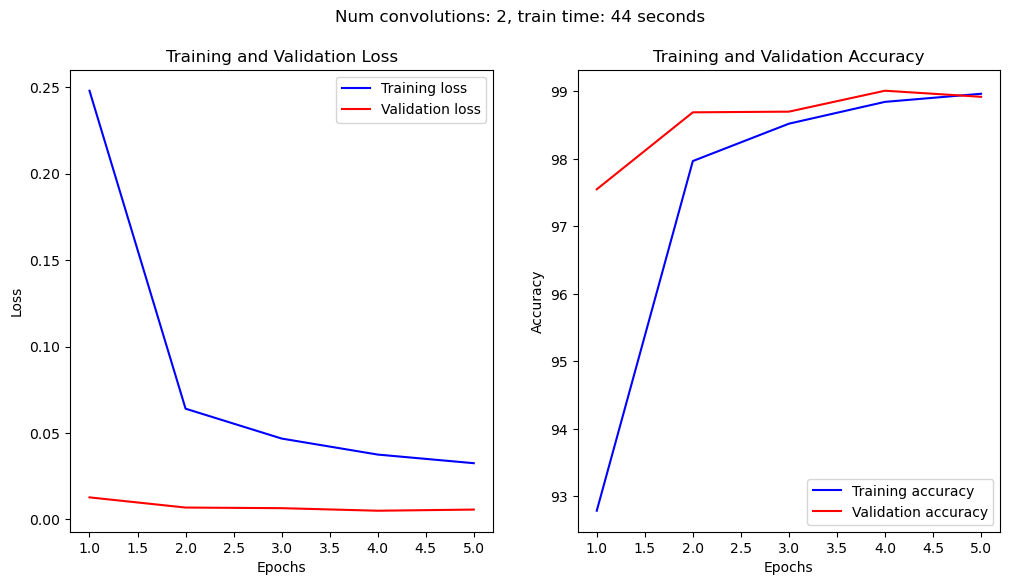

Epoch [1/5], Train Loss: 0.2586, Train Acc: 91.89%, Val Loss: 0.0103, Val Acc: 98.14%
Epoch [2/5], Train Loss: 0.0656, Train Acc: 98.02%, Val Loss: 0.0100, Val Acc: 98.09%
Epoch [3/5], Train Loss: 0.0456, Train Acc: 98.57%, Val Loss: 0.0067, Val Acc: 98.69%
Epoch [4/5], Train Loss: 0.0358, Train Acc: 98.86%, Val Loss: 0.0066, Val Acc: 98.82%
Epoch [5/5], Train Loss: 0.0302, Train Acc: 99.04%, Val Loss: 0.0044, Val Acc: 99.15%


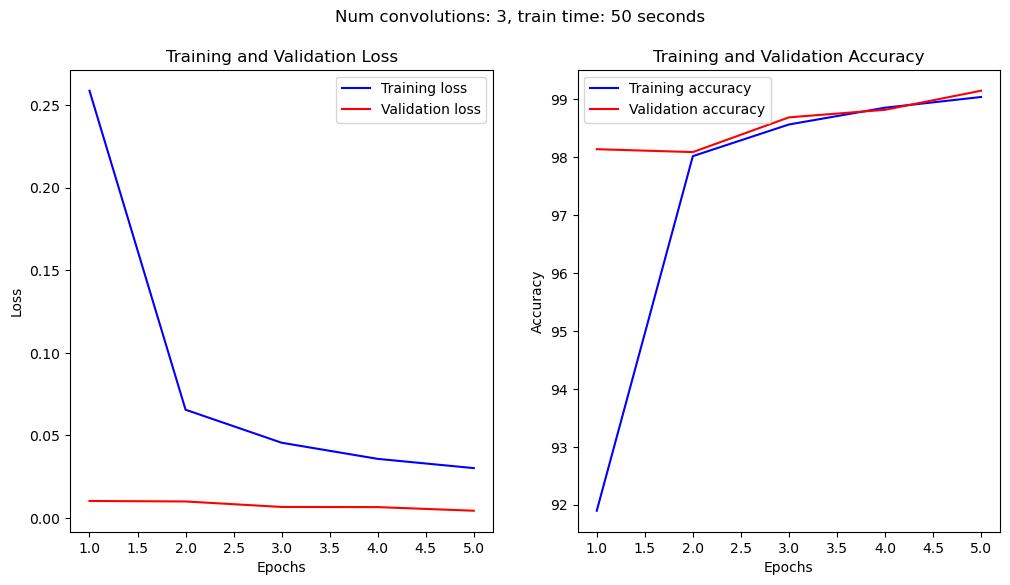

In [66]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for n_layers in [None, 2, 3]:
    model = MyCNN(n_layers=n_layers).to(device)

    start_time = datetime.now()
    train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, lr=0.001, n_epochs=5, device=device)
    end_time = datetime.now()

    train_time = (end_time - start_time).seconds

    plot_results(train_losses, val_losses, train_accuracies, val_accuracies, title=f'Num convolutions: {n_layers}, train time: {train_time} seconds')

Epoch [1/5], Train Loss: 0.2239, Train Acc: 93.63%, Val Loss: 0.0159, Val Acc: 97.39%
Epoch [2/5], Train Loss: 0.0806, Train Acc: 97.68%, Val Loss: 0.0104, Val Acc: 98.12%
Epoch [3/5], Train Loss: 0.0627, Train Acc: 98.11%, Val Loss: 0.0114, Val Acc: 98.01%
Epoch [4/5], Train Loss: 0.0522, Train Acc: 98.41%, Val Loss: 0.0101, Val Acc: 98.20%
Epoch [5/5], Train Loss: 0.0458, Train Acc: 98.57%, Val Loss: 0.0085, Val Acc: 98.45%


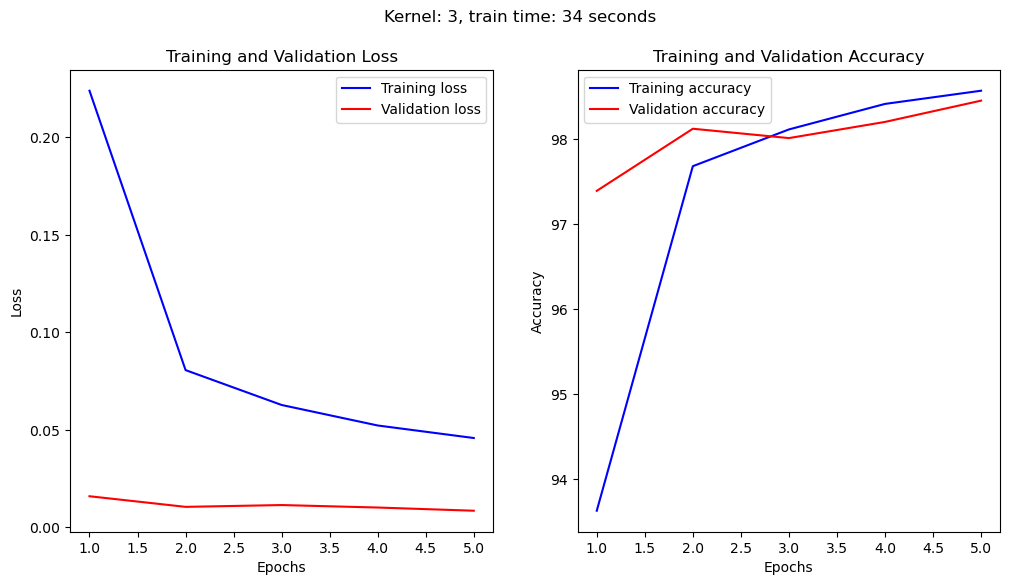

Epoch [1/5], Train Loss: 0.2548, Train Acc: 92.86%, Val Loss: 0.0164, Val Acc: 96.89%
Epoch [2/5], Train Loss: 0.0811, Train Acc: 97.55%, Val Loss: 0.0110, Val Acc: 97.84%
Epoch [3/5], Train Loss: 0.0611, Train Acc: 98.14%, Val Loss: 0.0101, Val Acc: 97.90%
Epoch [4/5], Train Loss: 0.0502, Train Acc: 98.46%, Val Loss: 0.0068, Val Acc: 98.54%
Epoch [5/5], Train Loss: 0.0444, Train Acc: 98.61%, Val Loss: 0.0067, Val Acc: 98.58%


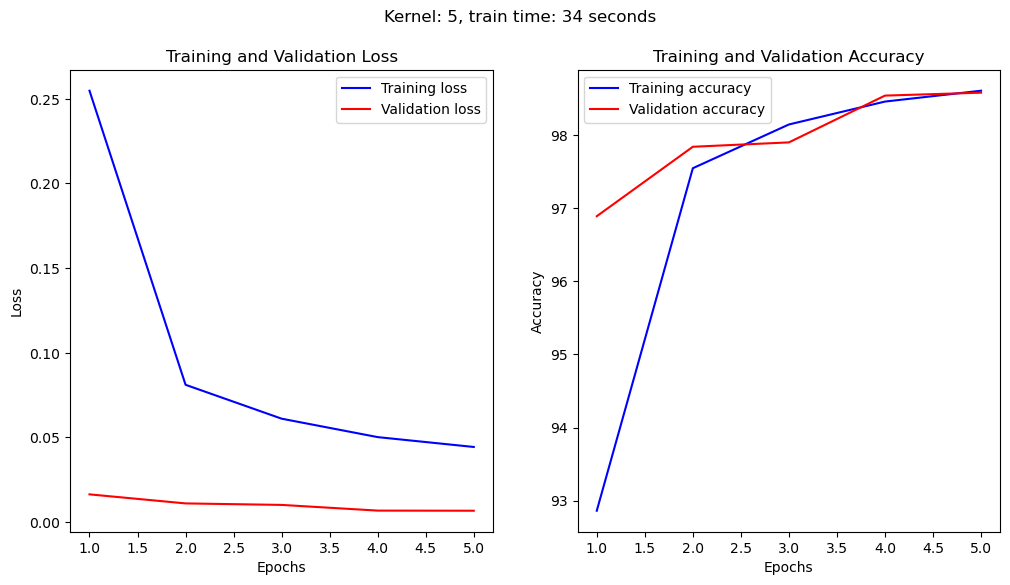

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x576 and 1024x10)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for kernel_size in [3, 5]:
    model = MyCNN(kernel_size=kernel_size).to(device)

    start_time = datetime.now()
    train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, lr=0.001, n_epochs=5, device=device)
    end_time = datetime.now()

    train_time = (end_time - start_time).seconds

    plot_results(train_losses, val_losses, train_accuracies, val_accuracies, title=f'Kernel: {kernel_size}, train time: {train_time} seconds')

Epoch [1/5], Train Loss: 0.2270, Train Acc: 93.48%, Val Loss: 0.0146, Val Acc: 97.47%
Epoch [2/5], Train Loss: 0.0819, Train Acc: 97.55%, Val Loss: 0.0102, Val Acc: 98.13%
Epoch [3/5], Train Loss: 0.0631, Train Acc: 98.15%, Val Loss: 0.0092, Val Acc: 98.31%
Epoch [4/5], Train Loss: 0.0535, Train Acc: 98.40%, Val Loss: 0.0091, Val Acc: 98.28%
Epoch [5/5], Train Loss: 0.0470, Train Acc: 98.61%, Val Loss: 0.0091, Val Acc: 98.29%


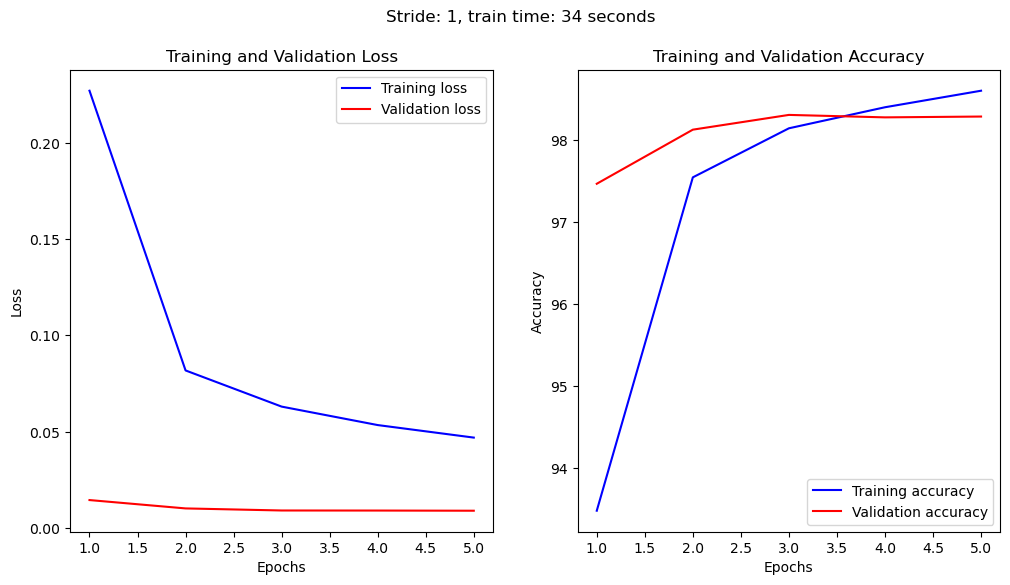

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x576 and 1024x10)

In [68]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for stride in [1, 3, 5]:
    model = MyCNN(stride=stride).to(device)

    start_time = datetime.now()
    train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, lr=0.001, n_epochs=5, device=device)
    end_time = datetime.now()

    train_time = (end_time - start_time).seconds

    plot_results(train_losses, val_losses, train_accuracies, val_accuracies, title=f'Stride: {stride}, train time: {train_time} seconds')

Epoch [1/5], Train Loss: 0.2242, Train Acc: 93.72%, Val Loss: 0.0152, Val Acc: 97.39%
Epoch [2/5], Train Loss: 0.0782, Train Acc: 97.68%, Val Loss: 0.0123, Val Acc: 97.71%
Epoch [3/5], Train Loss: 0.0615, Train Acc: 98.09%, Val Loss: 0.0094, Val Acc: 98.23%
Epoch [4/5], Train Loss: 0.0520, Train Acc: 98.45%, Val Loss: 0.0089, Val Acc: 98.35%
Epoch [5/5], Train Loss: 0.0447, Train Acc: 98.70%, Val Loss: 0.0079, Val Acc: 98.50%


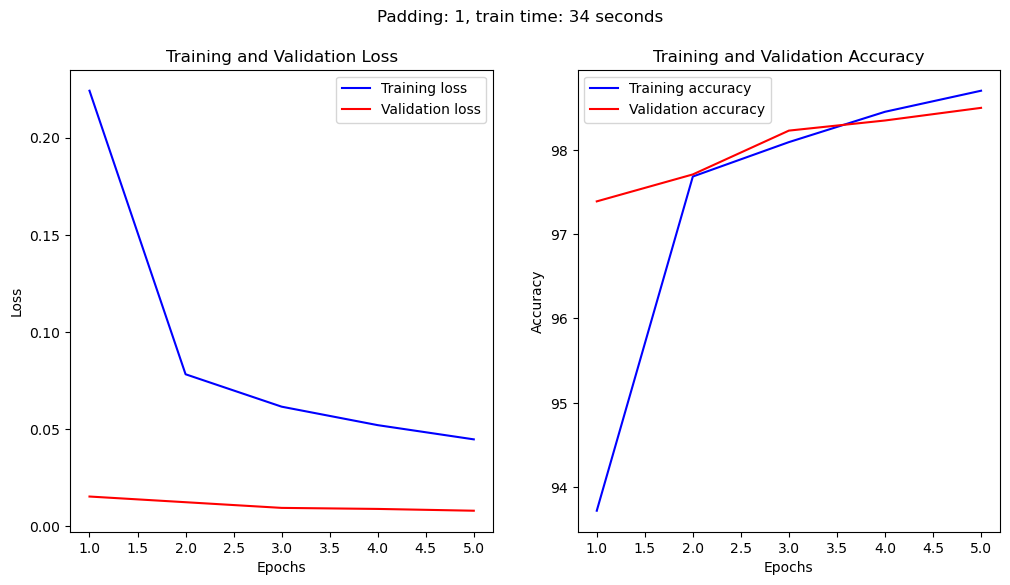

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x6400 and 5184x10)

In [69]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for padding in [1, 3, 5]:
    model = MyCNN(padding=padding).to(device)

    start_time = datetime.now()
    train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, lr=0.001, n_epochs=5, device=device)
    end_time = datetime.now()

    train_time = (end_time - start_time).seconds

    plot_results(train_losses, val_losses, train_accuracies, val_accuracies, title=f'Padding: {padding}, train time: {train_time} seconds')

### **Задание 3. Сравнение функций активации в нейронных сетях**
1. Для базового MLP и/или CNN реализуйте варианты с разными функциями активации: ReLU, sigmoid, tanh.
2. Обучите модели на одном и том же наборе данных и зафиксируйте метрики (точность, скорость сходимости, значение функции потерь).
3. Постройте графики изменения метрик в зависимости от выбранной функции активации.
4. Проанализируйте преимущества и недостатки каждой функции активации в контексте решения задач компьютерного зрения.

Epoch [1/5], Train Loss: 0.3307, Train Acc: 89.91%, Val Loss: 0.0241, Val Acc: 95.56%
Epoch [2/5], Train Loss: 0.1258, Train Acc: 96.17%, Val Loss: 0.0167, Val Acc: 96.92%
Epoch [3/5], Train Loss: 0.0880, Train Acc: 97.26%, Val Loss: 0.0167, Val Acc: 96.97%
Epoch [4/5], Train Loss: 0.0678, Train Acc: 97.85%, Val Loss: 0.0138, Val Acc: 97.42%
Epoch [5/5], Train Loss: 0.0532, Train Acc: 98.30%, Val Loss: 0.0128, Val Acc: 97.60%


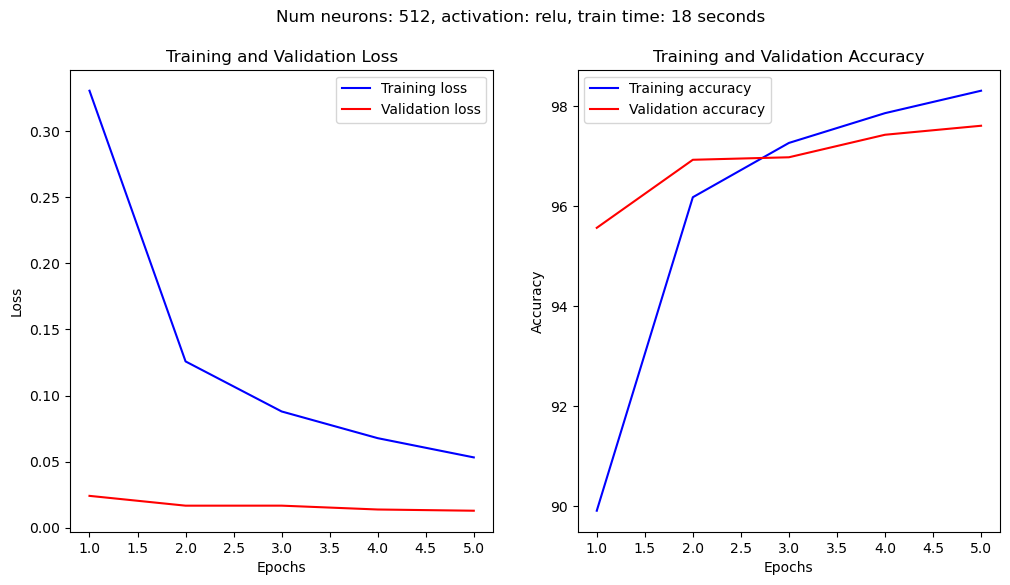

Epoch [1/5], Train Loss: 0.3098, Train Acc: 90.89%, Val Loss: 0.0235, Val Acc: 95.72%
Epoch [2/5], Train Loss: 0.1216, Train Acc: 96.31%, Val Loss: 0.0182, Val Acc: 96.60%
Epoch [3/5], Train Loss: 0.0836, Train Acc: 97.40%, Val Loss: 0.0143, Val Acc: 97.51%
Epoch [4/5], Train Loss: 0.0642, Train Acc: 97.97%, Val Loss: 0.0150, Val Acc: 97.23%
Epoch [5/5], Train Loss: 0.0505, Train Acc: 98.38%, Val Loss: 0.0127, Val Acc: 97.78%


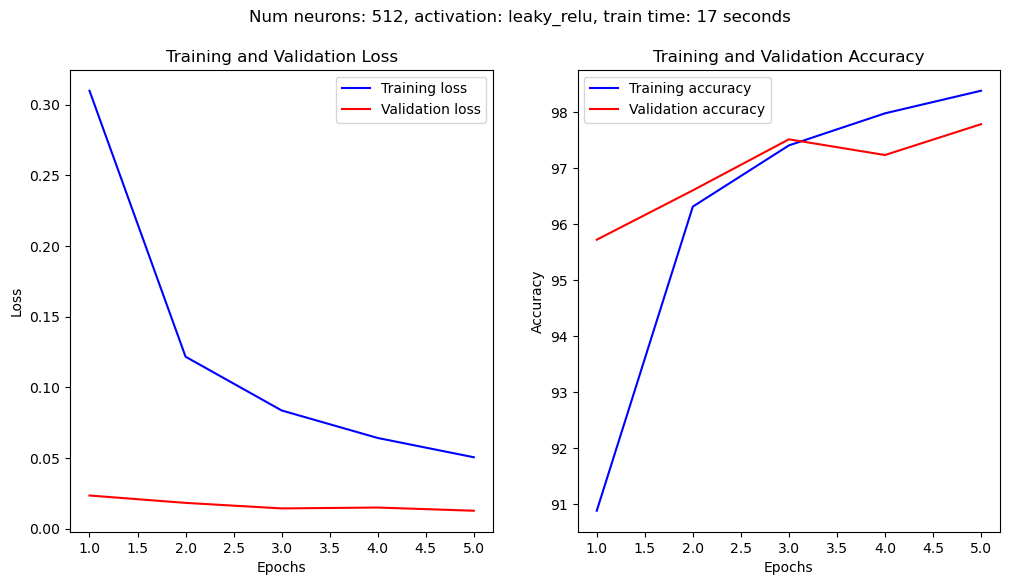

Epoch [1/5], Train Loss: 0.6871, Train Acc: 79.91%, Val Loss: 0.0445, Val Acc: 92.45%
Epoch [2/5], Train Loss: 0.2171, Train Acc: 93.80%, Val Loss: 0.0302, Val Acc: 94.82%
Epoch [3/5], Train Loss: 0.1477, Train Acc: 95.74%, Val Loss: 0.0234, Val Acc: 95.85%
Epoch [4/5], Train Loss: 0.1125, Train Acc: 96.76%, Val Loss: 0.0190, Val Acc: 96.66%
Epoch [5/5], Train Loss: 0.0886, Train Acc: 97.35%, Val Loss: 0.0177, Val Acc: 96.88%


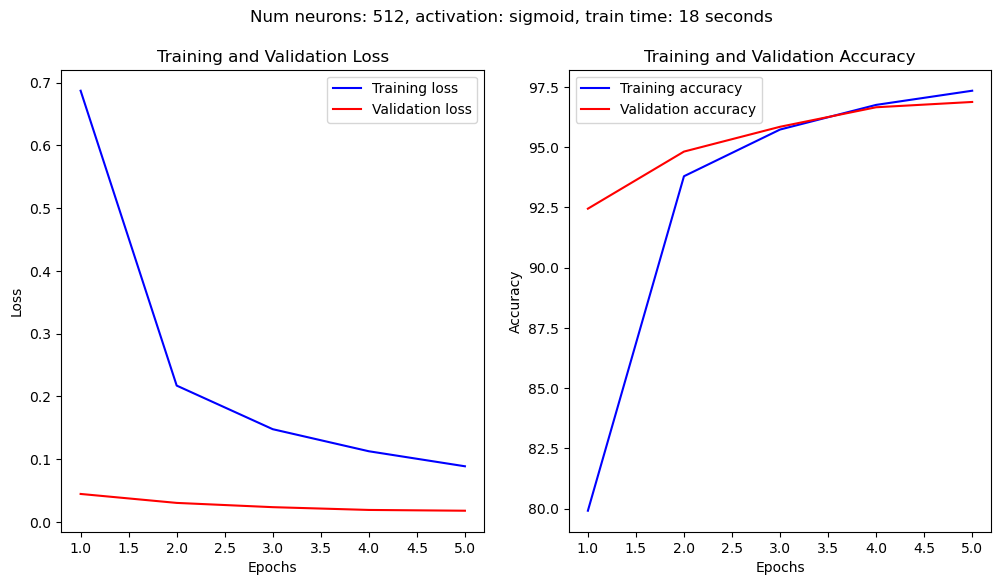

Epoch [1/5], Train Loss: 0.3049, Train Acc: 91.08%, Val Loss: 0.0267, Val Acc: 95.17%
Epoch [2/5], Train Loss: 0.1333, Train Acc: 95.97%, Val Loss: 0.0196, Val Acc: 96.56%
Epoch [3/5], Train Loss: 0.0944, Train Acc: 97.08%, Val Loss: 0.0178, Val Acc: 96.82%
Epoch [4/5], Train Loss: 0.0707, Train Acc: 97.84%, Val Loss: 0.0176, Val Acc: 96.92%
Epoch [5/5], Train Loss: 0.0548, Train Acc: 98.24%, Val Loss: 0.0170, Val Acc: 96.87%


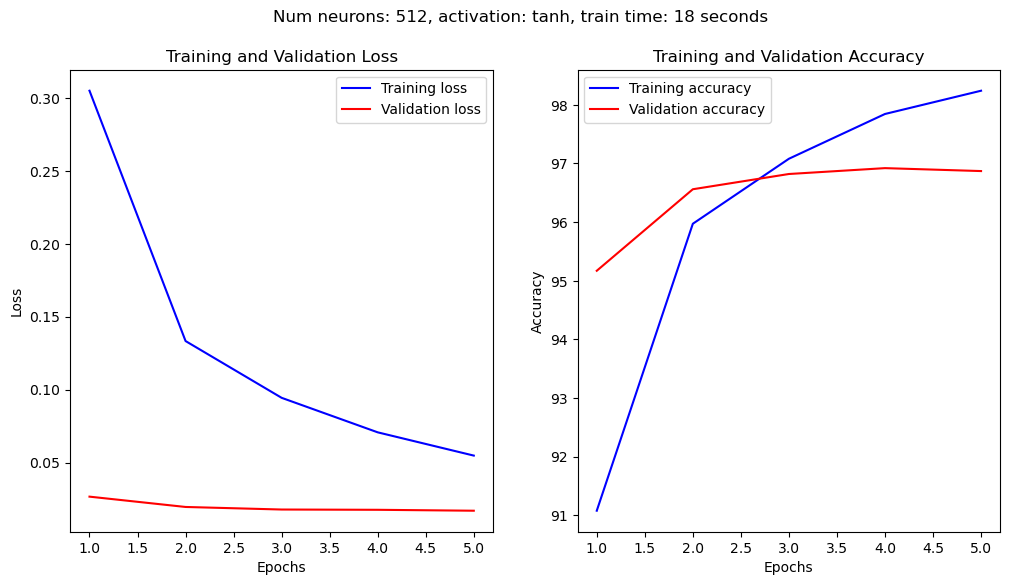

In [36]:
for activation in ['relu', 'leaky_relu', 'sigmoid', 'tanh']:
    model = MyMLP(n_neurons=128, activation=activation).to(device)

    start_time = datetime.now()
    train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, lr=0.001, n_epochs=5, device=device)
    end_time = datetime.now()

    train_time = (end_time - start_time).seconds

    plot_results(train_losses, val_losses, train_accuracies, val_accuracies, title=f'Num neurons: {n_neurons}, activation: {activation}, train time: {train_time} seconds')

### **Задание 4. Экспериментальное исследование оптимизаторов**
1. На примере выбранной CNN сравните эффективность различных оптимизаторов: SGD, Adam, RMSProp.
2. Для каждого оптимизатора зафиксируйте скорость сходимости, стабильность обучения и итоговую точность на валидационной выборке.
3. Постройте графики, показывающие изменение функции потерь и точности в процессе обучения.
4. Обсудите, какие гиперпараметры (например, скорость обучения) играют ключевую роль в эффективности оптимизатора.

### **Задание 5. Применение трансферного обучения**
1. Выберите предобученную модель (например, VGG16, ResNet) и загрузите её с предобученными весами.
2. Заморозьте базовые слои и добавьте новые полносвязанные слои для адаптации модели к вашей задаче (например, классификация по 10 классам).
3. Обучите модель на небольшом наборе данных и сравните результаты с моделью, обученной «с нуля».
4. Проанализируйте, как трансферное обучение влияет на скорость обучения и итоговую точность.

### **Задание 6. Визуализация работы сверточных слоев**
1. Реализуйте визуализацию активационных карт для одного или нескольких сверточных слоёв вашей CNN.
2. Используйте методы Grad-CAM или saliency maps для интерпретации, какие регионы изображения влияют на предсказание модели.
3. Сравните визуализации для правильно и неправильно классифицированных примеров.
4. Обсудите, какие признаки (края, текстуры, формы) наиболее значимы для модели.

### **Задание 7. Исследование параметров свёртки**
1. Экспериментируйте с различными значениями параметров свёрточного слоя: размер ядра, количество фильтров, шаг (stride) и тип padding.
2. Для каждого варианта визуализируйте выходные карты признаков.
3. Оцените, как эти параметры влияют на размерность выходных данных и на способность сети извлекать релевантные признаки.
4. Документируйте результаты экспериментов с комментариями и графиками.

### **Задание 8. Методы регуляризации в CNN**
1. Реализуйте в CNN методы регуляризации, такие как Dropout, Batch Normalization и Data Augmentation.
2. Проведите эксперименты, сравнивая модель с и без регуляризации, с точки зрения переобучения (overfitting).
3. Постройте графики функции потерь и точности для каждой версии модели.
4. Обсудите, какой вклад вносит каждый метод регуляризации в устойчивость модели.

### **Задание 9. Подбор гиперпараметров с использованием автоматизированных методов**
1. Используйте инструменты автоматизированного подбора гиперпараметров (например, Keras Tuner или аналогичный фреймворк) для вашей CNN.
2. Задайте диапазоны для основных гиперпараметров: число сверточных фильтров, размер ядер, скорость обучения, коэффициент dropout.
3. Проведите подбор оптимальных параметров с использованием Grid Search или Random Search.
4. Сравните результаты до и после оптимизации, проанализируйте улучшение качества модели.

### **Задание 10. Интерпретация и анализ ошибок модели**
1. Для обученной CNN постройте матрицу ошибок (confusion matrix) и визуализируйте её.
2. Проведите анализ наиболее частых ошибок классификации: какие классы путаются и почему.
3. Используйте методы интерпретации (например, Grad-CAM, occlusion sensitivity) для анализа сложных случаев.
4. Предложите пути улучшения модели на основе проведённого анализа (например, дообучение на сложных примерах или дополнительная аугментация данных).